# From Crystallizer candidates to a density-refined structure: α-Li₂SO₄

GEMDAT has two ways to get an average crystal structure out of an MD trajectory, and they
are good at different things.

- The **Crystallizer** (`gemdat.Crystallizer`) works on *geometry*. It picks the peaks out of
  the mobile-ion density, time-averages the framework, and scans the symmetry tolerance.
  That tells you which space groups the positions are compatible with, and how far each
  one is from them (the `deviation`, in Å). It is fast and needs no prior knowledge. But it
  only sees peak positions: it says nothing about how the density is shared between sites,
  how broad they are, or whether a site is split, and it cannot handle a species with no
  clear peaks.
- **Density crystallography** (`gemdat.density_crystallography`) fits a symmetry-constrained
  Gaussian mixture *directly to the density grid*. It refines widths (*U*<sub>iso</sub>),
  fractions and split positions, and compares models on the same grid. But it needs to be
  told the space group and where to start.

This notebook combines them: **the Crystallizer proposes the symmetries, the density method
works them out.** The link is `from_crystallizer`. It turns one crystallized result into the
space-group operations (in the trajectory's own basis and origin, so no change of setting
is needed) and one starting site per orbit, both ready for the density functions.

1. **The trajectory.**
2. **Candidates from the Crystallizer**: space groups for the S + Li geometry, and why O
   gives none.
3. **Candidates → density models** with `from_crystallizer`.
4. **Screening the candidates on the density**: is the lower symmetry real, or noise?
5. **Working out the structure** in the group that survives: S, Li (missing site, split
   site, inversion centre) and O.
6. **Summary**: what each tool found.

The data is T. Famprikis's ab initio MD run of plastic-crystal α-Li₂SO₄ (2×2×2 supercell of
the Fm-3m cell, 224 atoms, 1000 K), the same trajectory as in the
[density crystallography notebook](density_crystallography.ipynb), which compares the fits
in more depth with the published Table I. The cache (`vasprun.xml.12a3e781.cache`, 435 MB)
is not part of the repository, so point `DATA` at your copy.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import map_coordinates

from gemdat import Crystallizer, Trajectory
from gemdat.density_crystallography import (
    crystallographic_density_metrics,
    fit_density_model,
    fold_supercell,
    from_crystallizer,
    rank_spacegroups,
    site_free_directions,
    symmetrize_density,
    wyckoff_orbit,
)

DATA = Path('../../local/li2so4/vasprun.xml.12a3e781.cache')
EQUILIBRATION_CUTOFF = 6007  # frames dropped as equilibration, as in the reference scripts
RESOLUTION = 0.16  # Å, for the Crystallizer and the density grids alike
SUPERCELL = (2, 2, 2)
ATOMS_PER_CELL = {'S': 4, 'Li': 8, 'O': 16}  # conventional Fm-3m cell, Z = 4

Plot helpers, as in the density crystallography notebook. Densities use a single-hue scale;
residuals use a diverging scale that is grey at zero (blue: observed above model, orange:
model above observed). Planes are sampled from the periodic grid with voxel `i` centred on
(i+½)/n, the `Volume` convention.

In [2]:
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, GRID = '#0b0b0b', '#52514e', '#e3e2dd'

SEQ = LinearSegmentedColormap.from_list(
    'seq', ['#fcfcfb', '#d6e5f7', '#8db8ec', '#2a78d6', '#154a8c', '#0b2748']
)
DIV = LinearSegmentedColormap.from_list(
    'div', ['#7a2e0e', ORANGE, '#f4c7b0', '#e8e7e3', '#b5d0f2', BLUE, '#0f3a6e']
)

plt.rcParams.update(
    {
        'figure.dpi': 100,
        'font.size': 10,
        'axes.edgecolor': MUTED,
        'axes.labelcolor': INK,
        'axes.titlecolor': INK,
        'axes.titlesize': 10,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': True,
        'grid.color': GRID,
        'grid.linewidth': 0.6,
        'xtick.color': MUTED,
        'ytick.color': MUTED,
        'legend.frameon': False,
        'lines.linewidth': 2,
        'axes.axisbelow': True,
    }
)


def sample(grid, frac):
    # Interpolate a periodic grid at fractional coordinates frac (..., 3).
    idx = np.mod(frac, 1.0) * np.array(grid.shape) - 0.5
    return map_coordinates(grid, np.moveaxis(idx, -1, 0), order=1, mode='grid-wrap')


def plane(grid, origin, e1, e2, n=176):
    # Density on origin + u*e1 + v*e2 for u, v in [0, 1), as an imshow image (rows = v).
    t = (np.arange(n) + 0.5) / n
    u, v = np.meshgrid(t, t, indexing='ij')
    frac = np.asarray(origin) + u[..., None] * np.asarray(e1) + v[..., None] * np.asarray(e2)
    return sample(grid, frac).T


def show(
    ax,
    image,
    *,
    extent=(0, 1, 0, 1),
    cmap=SEQ,
    vmin=None,
    vmax=None,
    title='',
    labels=('x', 'y'),
):
    im = ax.imshow(image, origin='lower', extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set(title=title, xlabel=labels[0], ylabel=labels[1])
    ax.grid(False)
    return im


DIAGONAL_PLANE = dict(
    origin=(0, 0, 0),
    e1=(1, 1, 0),
    e2=(0, 0, 1),
    extent=(0, np.sqrt(2), 0, 1),
    labels=('[110] (a)', '[001] (a)'),
)


def compare_maps(
    observed, model, *, origin, e1, e2, title, labels=('x', 'y'), extent=(0, 1, 0, 1)
):
    # Observed | model | observed - model on one plane, both grids normalised to sum 1.
    o = plane(observed / observed.sum(), origin, e1, e2)
    m = plane(model / model.sum(), origin, e1, e2)
    vmax = max(o.max(), m.max())
    rmax = np.abs(o - m).max()
    fig, axs = plt.subplots(1, 3, figsize=(12, 3.9), layout='constrained')
    show(axs[0], o, vmin=0, vmax=vmax, title='observed', labels=labels, extent=extent)
    im = show(axs[1], m, vmin=0, vmax=vmax, title='model', labels=labels, extent=extent)
    fig.colorbar(im, ax=axs[:2], shrink=0.85, label='density (normalised)')
    im = show(
        axs[2],
        o - m,
        cmap=DIV,
        vmin=-rmax,
        vmax=rmax,
        title='observed − model',
        labels=labels,
        extent=extent,
    )
    fig.colorbar(im, ax=axs[2], shrink=0.85, label='residual')
    fig.suptitle(title, color=INK)
    return fig


def line(grid, start, stop, n=241):
    t = np.linspace(0, 1, n)
    frac = np.asarray(start) + t[:, None] * (np.asarray(stop) - np.asarray(start))
    return t, sample(grid, frac)


def sites_table(result):
    # One row per refined orbit; site occupancy = atoms per cell * fraction / multiplicity.
    return pd.DataFrame(
        [
            {
                'specie': site.specie,
                'multiplicity': site.multiplicity,
                'position': tuple(float(v) for v in np.round(site.position, 4) % 1),
                'density fraction': round(site.occupancy, 4),
                'site occupancy': round(
                    ATOMS_PER_CELL[site.specie] * site.occupancy / site.multiplicity, 4
                ),
                'U_iso (Å²)': round(site.u_iso, 4),
                'split (Å)': None if site.displacement is None else round(site.displacement, 3),
            }
            for site in result.sites
        ]
    )

## 1. The trajectory

Load the cache, correct the drift using the sulfur atoms and drop the first 6007 frames as
equilibration. Li diffuses, S vibrates about its site, and the SO₄²⁻ ions tumble in place,
so the O atoms smear out over a shell around each S (see the density crystallography
notebook for the plots).

In [3]:
full = Trajectory.from_cache(DATA)
traj = full.apply_drift_correction(fixed_species=['S'])[EQUILIBRATION_CUTOFF:]
del full

a = traj.lattice[0, 0] / SUPERCELL[0]  # conventional cell edge
pd.Series(
    {
        'composition': traj.get_structure(0).composition.formula,
        'temperature (K)': traj.metadata['temperature'],
        'frames used': len(traj),
        'time used (ps)': round(len(traj) * traj.time_step * 1e12, 1),
        'supercell edge (Å)': round(traj.lattice[0, 0], 3),
        'conventional a (Å)': round(a, 3),
    }
).to_frame('value')

,value
composition,Li64 S32 O128
temperature (K),1000.0
frames used,75000
time used (ps),150.0
supercell edge (Å),14.22
conventional a (Å),7.11


## 2. Candidate symmetries from the Crystallizer

The Crystallizer treats every species except the floating one as a static framework and
takes its time-averaged positions. For S that is fine. For O it is not: a tumbling sulfate's
O atoms average to a point near the S, which is no structure at all. So the scan uses only
S (framework) and Li (mobile). At `background_level=0.3` the Li density gives one peak per
tetrahedral site.

In [4]:
crystallizer = Crystallizer.from_trajectory(
    traj.filter(['S', 'Li']), 'Li', resolution=RESOLUTION
)
scan = crystallizer.scan(background_level=0.3)

n_li_peaks = sum(site.specie.symbol == 'Li' for site in scan.geometry)
print(f'{n_li_peaks} Li peaks (64 tetrahedral sites in the supercell)\n')
print(scan.format())

64 Li peaks (64 tetrahedral sites in the supercell)

symprec (Å)  deviation (Å)  angle dev (°)  space group  #    crystal system  # ops  # orbits  # hits
-----------  -------------  -------------  -----------  ---  --------------  -----  --------  ------
0.01         0              0              P1           1    triclinic       1      96        28    
0.165872     0.07416        0              P-1          2    triclinic       2      48        6     
0.302798     0.2012         0              Fm-3m        225  cubic           1536   2         6     


Three groups. At a tight tolerance the geometry is P1. Loosening it to 0.17 Å reaches P-1,
and at 0.30 Å everything snaps to **Fm-3m**, with S on 4a and Li on the tetrahedral 8c site.
The `deviation` column is what each group costs: the peaks have to move up to 0.07 Å for
P-1, and up to 0.20 Å for Fm-3m.

`scan.best()` would take Fm-3m. But is a 0.2 Å deviation just scatter in where the peaks
were found, or a real distortion that P-1 describes? The peak positions cannot tell. Nor can
they show anything that is not a peak: the Crystallizer has found no octahedral Li.

And O on its own? Here O is the floating species, with S as the framework:

In [5]:
scan_O = Crystallizer.from_trajectory(traj.filter(['S', 'O']), 'O', resolution=RESOLUTION).scan(
    background_level=0.3
)
n_o_peaks = sum(site.specie.symbol == 'O' for site in scan_O.geometry)
print(f'{n_o_peaks} O "peaks" (128 O atoms in the supercell)\n')
print(scan_O.format())

123 O "peaks" (128 O atoms in the supercell)

symprec (Å)  deviation (Å)  angle dev (°)  space group  #  crystal system  # ops  # orbits  # hits
-----------  -------------  -------------  -----------  -  --------------  -----  --------  ------
0.01         0              0              P1           1  triclinic       1      155       27    


Only P1, from a set of peaks that matches nothing (lower backgrounds do not help: the
watershed basins then hold more than one O atom and the site extraction fails). The O
density is a continuous shell with lobes, not a set of separated peaks. O will have to be
found by the density method, inside a group that S and Li have fixed.

## 3. From candidates to density models

`from_crystallizer(result, supercell=...)` returns the operations spglib found for the
crystallized structure and one site per orbit, moved exactly onto its site symmetry. With
`supercell=(2, 2, 2)` both are expressed in the conventional cell, so they go with the
folded 44³ grid. That only works if the group contains the translations between the eight
cells; if not, `from_crystallizer` raises, and the candidate has to be tested on the 88³
supercell grid (`supercell=1`).

In [6]:
candidates = {}
rows = []
for level in scan.candidates:
    result = scan.at_level(level)
    try:
        ops, sites = from_crystallizer(result, supercell=SUPERCELL)
        cell = 'folded 44³'
    except ValueError:
        ops, sites = from_crystallizer(result)
        cell = 'supercell 88³'
    candidates[result.spacegroup_symbol] = (cell, ops, sites)
    rows.append(
        {
            'space group': result.spacegroup_symbol,
            'symprec (Å)': round(result.symprec, 3),
            'deviation (Å)': round(level.deviation, 3),
            'grid': cell,
            'operations': len(ops),
            'S orbits': sum(s['specie'] == 'S' for s in sites),
            'Li orbits': sum(s['specie'] == 'Li' for s in sites),
        }
    )
pd.DataFrame(rows).set_index('space group')

,symprec (Å),deviation (Å),grid,operations,S orbits,Li orbits
space group,,,,,,
Fm-3m,0.303,0.201,folded 44³,192,1,1
P-1,0.166,0.074,supercell 88³,2,16,32
P1,0.010,0.000,supercell 88³,1,32,64


In [7]:
fm3m, fm3m_sites = candidates['Fm-3m'][1:]
pd.DataFrame(
    [
        {
            'specie': s['specie'],
            'position': tuple(float(v) for v in np.round(s['position'], 4) % 1),
        }
        for s in fm3m_sites
    ]
)

,specie,position
0,S,"(0.0, 0.0, 0.0)"
1,Li,"(0.25, 0.75, 0.25)"


Fm-3m folds: its 192 operations act on the conventional cell, and its two sites are S at
the origin (4a) and Li at (¼, ¾, ¼) (8c), exactly where the drift correction put them.
P-1 and P1 do not fold. They hold only for the supercell as a whole, with 48 and 96
independent Li sites. Fitting a Gaussian per orbit would mean about 100 free parameters, so
instead of fitting them, the next step asks whether the density needs them at all.

## 4. Screening the candidates on the density

Symmetrising a density with a group averages it over the group's operations. If the density
really has that symmetry, this removes only sampling noise; if it does not, it also removes
signal. So compare how much symmetrising changes the density, *R*<sub>sym</sub> =
R1(observed, symmetrised), with how noisy the density is. The noise is measured from the data:
split the run into two halves and compare their densities. The difference of two halves has
twice the noise of the full run, so the noise estimate is *R*<sub>noise</sub> = R1(first half,
second half) / 2.

A ratio *R*<sub>sym</sub> / *R*<sub>noise</sub> near 1 or below means the group removes no
more than noise; well above 1 means the density breaks that symmetry.

In [8]:
li = traj.filter('Li')
half = len(li) // 2
li_grids = {
    'full': li.to_volume(resolution=RESOLUTION).data,
    'first half': li[:half].to_volume(resolution=RESOLUTION).data,
    'second half': li[half:].to_volume(resolution=RESOLUTION).data,
}


def r1(observed, model):
    return crystallographic_density_metrics(observed, model)['r1_like']


screen = []
symmetrised = {}
for symbol, (cell, ops, _) in candidates.items():
    grids = {
        k: fold_supercell(g, SUPERCELL) if cell.startswith('folded') else g
        for k, g in li_grids.items()
    }
    symmetrised[symbol] = symmetrize_density(grids['full'], ops)
    r_sym = r1(grids['full'], symmetrised[symbol])
    r_noise = r1(grids['first half'], grids['second half']) / 2
    screen.append(
        {
            'space group': symbol,
            'grid': cell,
            'R_sym': round(r_sym, 3),
            'R_noise': round(r_noise, 3),
            'R_sym / R_noise': round(r_sym / r_noise, 2),
        }
    )
pd.DataFrame(screen).set_index('space group')

,grid,R_sym,R_noise,R_sym / R_noise
space group,,,,
Fm-3m,folded 44³,0.180,0.174,1.04
P-1,supercell 88³,0.298,0.428,0.70
P1,supercell 88³,0.000,0.428,0.00


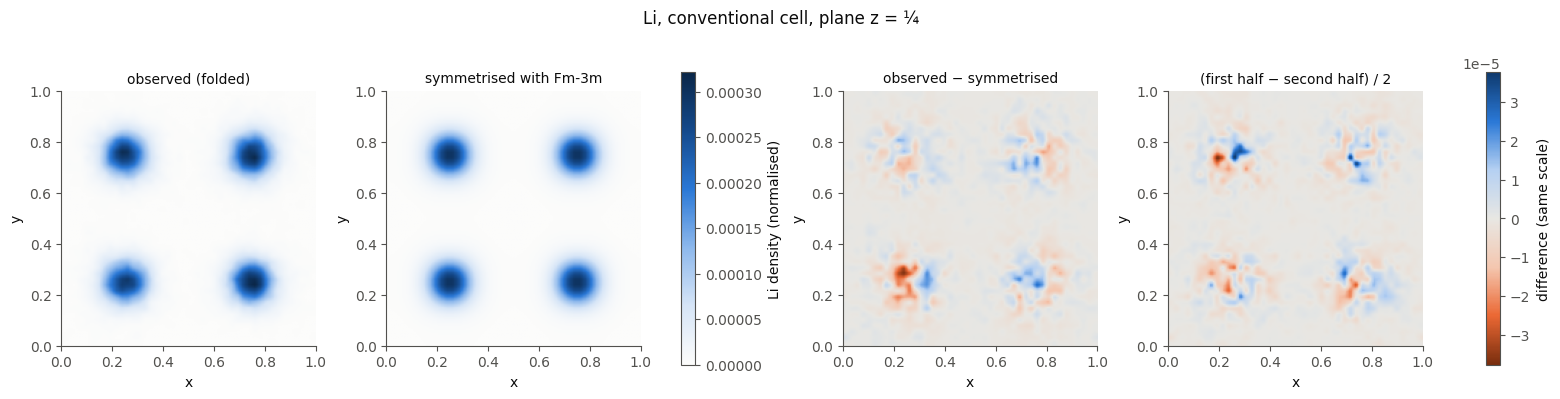

In [9]:
folded = {k: fold_supercell(g, SUPERCELL) for k, g in li_grids.items()}
observed = folded['full'] / folded['full'].sum()
halves = [folded[k] / folded[k].sum() for k in ('first half', 'second half')]
view = dict(origin=(0, 0, 0.25), e1=(1, 0, 0), e2=(0, 1, 0))

images = {
    'observed (folded)': plane(observed, **view),
    'symmetrised with Fm-3m': plane(symmetrised['Fm-3m'] / symmetrised['Fm-3m'].sum(), **view),
}
differences = {
    'observed − symmetrised': images['observed (folded)'] - images['symmetrised with Fm-3m'],
    '(first half − second half) / 2': plane((halves[0] - halves[1]) / 2, **view),
}
vmax = max(i.max() for i in images.values())
rmax = max(np.abs(d).max() for d in differences.values())

fig, axs = plt.subplots(1, 4, figsize=(15.5, 4), layout='constrained')
for ax, (title, image) in zip(axs[:2], images.items()):
    im = show(ax, image, vmin=0, vmax=vmax, title=title)
fig.colorbar(im, ax=axs[:2], shrink=0.8, label='Li density (normalised)')
for ax, (title, image) in zip(axs[2:], differences.items()):
    im = show(ax, image, cmap=DIV, vmin=-rmax, vmax=rmax, title=title)
fig.colorbar(im, ax=axs[2:], shrink=0.8, label='difference (same scale)')
fig.suptitle('Li, conventional cell, plane z = ¼', color=INK)
plt.show()

For Fm-3m the ratio is about 1: symmetrising takes out as much as the two halves of the run
disagree with each other, and no more. The two difference maps look alike, with speckle
spread over every tetrahedral site and no pattern that repeats by a lower symmetry. The Li
distribution simply has not fully averaged over 150 ps.

P-1 and P1 look "better" (their ratios are lower), but only because they are tested on the
supercell grid, where each voxel holds eight times fewer counts, and because they keep more
of the noise. P1 changes nothing and so trivially passes. What matters is that the highest
symmetry the Crystallizer offered, **Fm-3m, is already within the noise**, so its 0.2 Å
deviation is peak-finding scatter, not a distortion. The lower groups only add parameters
to fit noise, and the rest of the notebook works in Fm-3m.

## 5. Working out the structure in Fm-3m

Fold and symmetrise all three species with the Fm-3m operations from `from_crystallizer`.
Since the drift correction pins S to its starting sites, these operations coincide with the
standard setting of Fm-3m.

In [10]:
density = {
    sp: symmetrize_density(
        fold_supercell(traj.filter(sp).to_volume(resolution=RESOLUTION).data, SUPERCELL), fm3m
    )
    for sp in ('S', 'Li', 'O')
}
print('R1 between the Fm-3m operations from the Crystallizer and the standard setting:')
print(f"  {r1(density['Li'], symmetrize_density(folded['full'], 'Fm-3m')):.1e}")

FIT = dict(symmetrize=False, cell_length=a, seed=0, coarsen=2)
crystallizer_sites = {sp: [s for s in fm3m_sites if s['specie'] == sp] for sp in ('S', 'Li')}

R1 between the Fm-3m operations from the Crystallizer and the standard setting:


  7.5e-05


### 5a. Sulfur

The Crystallizer's S site, one isotropic Gaussian on 4a:

In [11]:
fit_S = fit_density_model(density['S'], fm3m, crystallizer_sites['S'], **FIT)
display(sites_table(fit_S))
print(f"R1 = {fit_S.metrics['r1_like']:.3f}")

,specie,multiplicity,position,density fraction,site occupancy,U_iso (Å²),split (Å)
0,S,4,"(0.0, 0.0, 0.0)",1.0,1.0,0.1256,None


R1 = 0.025


S is well described by the Crystallizer's site: R1 ≈ 0.02, *U*<sub>iso</sub> ≈ 0.126 Å².

### 5b. Lithium

Start from what the Crystallizer found, Li on 8c only, and look at what is left over.

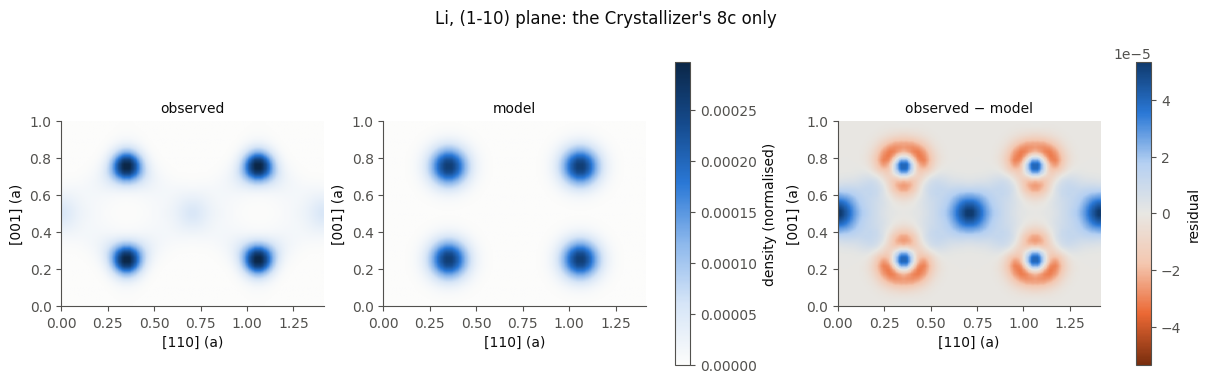

R1 = 0.502
largest residual at [0.511 0.511 0.489], i.e. [0.5 0.5 0.5]


free directions there: 0 (a fixed point: 4b)


In [12]:
fit_8c = fit_density_model(density['Li'], fm3m, crystallizer_sites['Li'], **FIT)
compare_maps(
    density['Li'],
    fit_8c.model_density,
    **DIAGONAL_PLANE,
    title="Li, (1-10) plane: the Crystallizer's 8c only",
)
plt.show()

residual = density['Li'] / density['Li'].sum() - fit_8c.model_density
peak = (np.array(np.unravel_index(np.argmax(residual), residual.shape)) + 0.5) / residual.shape[
    0
]
octahedral = np.round(peak * 4) / 4
print(f"R1 = {fit_8c.metrics['r1_like']:.3f}")
print(f'largest residual at {np.round(peak, 3)}, i.e. {octahedral}')
print(
    f'free directions there: {len(site_free_directions(fm3m, octahedral))} (a fixed point: 4b)'
)

With 8c alone R1 is 0.50: the model has to widen the tetrahedral Gaussian to cover density
that is not there, and the residual is a strong blob in the middle of the plane, at the
octahedral 4b site (½, ½, ½). The Crystallizer missed it because the octahedral density is
a low, broad bump rather than a peak above the background. Add 4b, then let the 8c site split
along ⟨111⟩ into 32f (x, x, x), which is a site the peak positions could not have suggested.

In [13]:
li_models = {
    '8c (Crystallizer)': crystallizer_sites['Li'],
    '8c + 4b': crystallizer_sites['Li'] + [{'specie': 'Li', 'position': octahedral}],
    '32f + 4b (split)': [
        dict(crystallizer_sites['Li'][0], free_position=(1, 1, 1), max_displacement=0.1),
        {'specie': 'Li', 'position': octahedral},
    ],
}
li_fits = {'8c (Crystallizer)': fit_8c}
li_fits.update(
    {
        name: fit_density_model(density['Li'], fm3m, sites, **FIT)
        for name, sites in li_models.items()
        if name not in li_fits
    }
)

display(pd.concat({name: sites_table(fit) for name, fit in li_fits.items()}))
best_bic = min(fit.metrics['bic'] for fit in li_fits.values())
pd.DataFrame(
    {
        name: {
            'parameters': len(fit.params),
            'R1-like': round(fit.metrics['r1_like'], 3),
            'ΔBIC': f"{fit.metrics['bic'] - best_bic:.3g}",
        }
        for name, fit in li_fits.items()
    }
)

specie  multiplicity               position  \
8c (Crystallizer) 0     Li             8     (0.25, 0.75, 0.25)   
8c + 4b           0     Li             8     (0.25, 0.75, 0.25)   
                  1     Li             4        (0.5, 0.5, 0.5)   
32f + 4b (split)  0     Li            32  (0.222, 0.722, 0.222)   
                  1     Li             4        (0.5, 0.5, 0.5)   

                     density fraction  site occupancy  U_iso (Å²) split (Å)  
8c (Crystallizer) 0            1.0000          1.0000      0.2510      None  
8c + 4b           0            0.7034          0.7034      0.1823      None  
                  1            0.2966          0.5932      0.6692      None  
32f + 4b (split)  0            0.6997          0.1749      0.1383     0.345  
                  1            0.3003          0.6006      0.6746       NaN

,8c (Crystallizer),8c + 4b,32f + 4b (split)
parameters,1,3,4
R1-like,0.502,0.179,0.151
ΔBIC,2.16e+05,3.19e+04,0


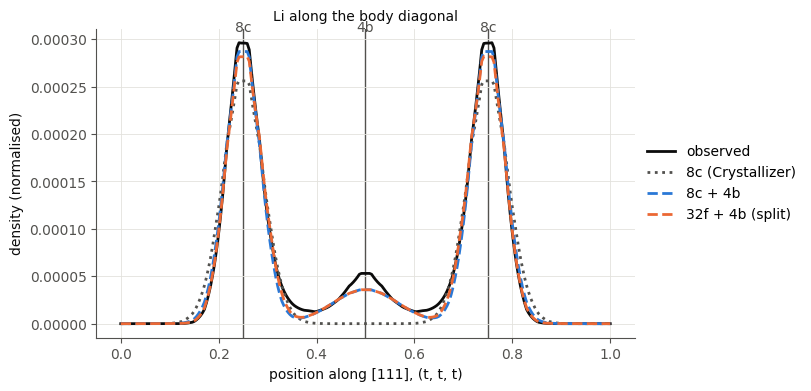

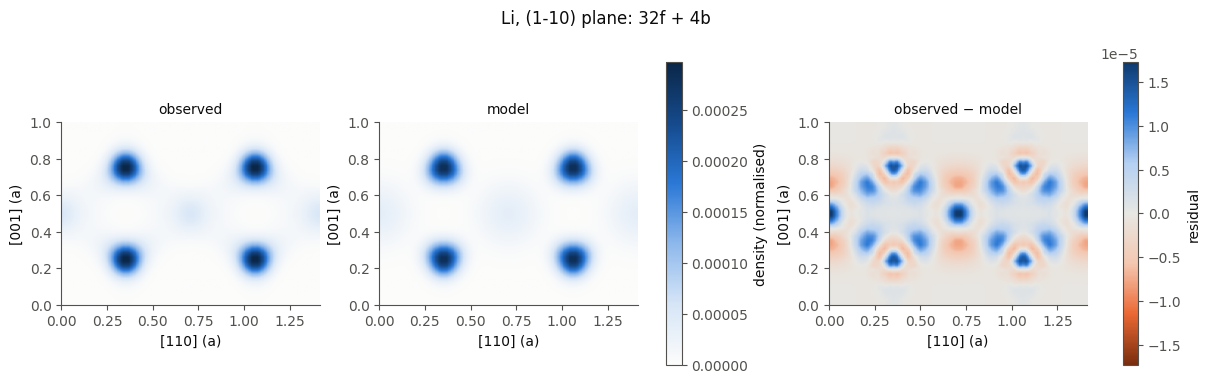

In [14]:
fig, ax = plt.subplots(figsize=(8, 3.8), layout='constrained')
t, observed_line = line(density['Li'] / density['Li'].sum(), (0, 0, 0), (1, 1, 1))
ax.plot(t, observed_line, color=INK, label='observed')
for (name, fit), color, ls in zip(li_fits.items(), (MUTED, BLUE, ORANGE), (':', '--', '--')):
    ax.plot(t, line(fit.model_density, (0, 0, 0), (1, 1, 1))[1], color=color, ls=ls, label=name)
for x, label in [(0.25, '8c'), (0.5, '4b'), (0.75, '8c')]:
    ax.axvline(x, color=MUTED, lw=1, zorder=0)
    ax.text(x, observed_line.max() * 1.04, label, ha='center', color=MUTED)
ax.set(
    xlabel='position along [111], (t, t, t)',
    ylabel='density (normalised)',
    title='Li along the body diagonal',
)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

compare_maps(
    density['Li'],
    li_fits['32f + 4b (split)'].model_density,
    **DIAGONAL_PLANE,
    title='Li, (1-10) plane: 32f + 4b',
)
plt.show()

Adding 4b takes R1 from 0.50 to 0.18: about 30 % of the Li density is on the octahedral
site, in a broad Gaussian (*U* ≈ 0.67 Å²). Splitting the tetrahedral site brings R1 to 0.15
and lowers BIC by another 3×10⁴. The four 32f sub-sites sit 0.35 Å from the tetrahedral
centre along ⟨111⟩, towards the neighbouring octahedral sites. The remaining misfit is at 4b
itself, where the observed density is a narrow peak on a broad base that one Gaussian cannot
follow.

### 5c. Is there an inversion centre?

Here the geometry-only Crystallizer is blind by construction. Its non-centrosymmetric
subgroup F-43m puts the tetrahedral sites at 4c (¼, ¼, ¼) and 4d (¾, ¾, ¾), which are *the
same positions* as Fm-3m 8c, so no peak-position scan can tell the two groups apart. Only
the density can: F-43m lets 4c and 4d carry different fractions and widths.
`rank_spacegroups` fits both groups and scores them on the same folded, *unsymmetrised* grid.

In [15]:
ranking = rank_spacegroups(
    folded['full'],
    [fm3m, 'F-43m'],
    [
        li_models['8c + 4b'],
        [
            {'specie': 'Li', 'position': (0.25, 0.25, 0.25)},
            {'specie': 'Li', 'position': (0.75, 0.75, 0.75)},
            {'specie': 'Li', 'position': (0.5, 0.5, 0.5)},
        ],
    ],
    cell_length=a,
    maxiter=100,
    popsize=15,
    coarsen=2,
)
best = ranking[0].ranking_metrics['bic']
pd.DataFrame(
    [
        {
            'space group': r.spacegroup_symbol,
            'parameters': len(r.params),
            'sites (fraction, U_iso)': '; '.join(
                f'{tuple(float(v) for v in np.round(s.position, 2))}: {s.occupancy:.3f}, {s.u_iso:.3f}'
                for s in r.sites
            ),
            'R1-like (common grid)': round(r.ranking_metrics['r1_like'], 4),
            'ΔBIC (common grid)': round(r.ranking_metrics['bic'] - best, 1),
        }
        for r in ranking
    ]
)

,space group,parameters,"sites (fraction, U_iso)",R1-like (common grid),ΔBIC (common grid)
0,F-43m,5,"(0.25, 0.25, 0.25): 0.351, 0.183; (0.75, 0.75,...",0.2627,0.0
1,Fm-3m,3,"(0.25, 0.75, 0.25): 0.703, 0.182; (0.5, 0.5, 0...",0.2627,9.9


F-43m ranks first by a ΔBIC of about 10, with the same R1 to four decimals, and its 4c and
4d fits are the same (fractions 0.351 and 0.352, widths 0.183 and 0.182 Å²): the Fm-3m
result split in two. Compared with the 3×10⁴ for the split site, and with BIC counting
85 184 correlated voxels as independent data, that is noise. The inversion centre holds,
and Fm-3m stays.

### 5d. Oxygen

The Crystallizer gave nothing for O, so let the density propose a site. Take the highest
voxel of the Fm-3m-symmetrised O density, and express it relative to the S it belongs to.

In [16]:
O_norm = density['O'] / density['O'].sum()
peak_O = (np.array(np.unravel_index(np.argmax(O_norm), O_norm.shape)) + 0.5) / O_norm.shape[0]
nearest_S = np.round(peak_O * 2) / 2  # 4a positions are the F-centred lattice points
offset = peak_O - nearest_S
_, y0, z0 = np.sort(np.abs(offset))  # the symmetry-equivalent (x <= y <= z) setting
print(f'highest O density at {np.round(peak_O, 4)}, near S at {nearest_S}')
print(
    f'offset {np.round(offset, 4)} -> (0, {y0:.4f}, {z0:.4f}), {np.linalg.norm(offset) * a:.2f} Å from S'
)

highest O density at [0.375  0.0114 0.6477], near S at [0.5 0.  0.5]
offset [-0.125   0.0114  0.1477] -> (0, 0.1250, 0.1477), 1.38 Å from S


The maximum sits 1.4 Å from S, at (0, y, z) to within a voxel, with y and z one voxel
(0.023) apart. So it is on, or right next to, the diagonal mirror y = z. That leaves two
Fm-3m models: **48h (0, y, y)**, one site on that mirror, and **96j (0, y, z)**, a pair of
sites on either side of it. Fit both with free
coordinates (`free_position=True` frees y for 48h, and y, z for 96j), starting from the
density maximum. These are the slow fits of the notebook (96 Gaussians per evaluation for
96j), so they run with `workers=2`.

In [17]:
o_models = {
    '48h (0, y, y)': (0.0, (y0 + z0) / 2, (y0 + z0) / 2),
    '96j (0, y, z)': (0.0, y0, z0),
}
o_fits = {
    name: fit_density_model(
        density['O'],
        fm3m,
        [{'specie': 'O', 'position': start, 'free_position': True}],
        maxiter=60,
        popsize=10,
        max_displacement=0.08,
        workers=2,
        **FIT,
    )
    for name, start in o_models.items()
}


def canonical(position):
    # Offset from the nearest S, sorted to the symmetry-equivalent (x <= y <= z) setting.
    return np.sort(np.abs(position - np.round(position * 2) / 2))


best_bic = min(fit.metrics['bic'] for fit in o_fits.values())
pd.DataFrame(
    [
        {
            'model': name,
            'parameters': len(fit.params),
            'position (0 ≤ x ≤ y ≤ z)': tuple(
                float(v) for v in np.round(canonical(fit.sites[0].position), 4)
            ),
            'S–O (Å)': round(np.linalg.norm(canonical(fit.sites[0].position)) * a, 3),
            'site occupancy': round(16 / fit.sites[0].multiplicity, 4),
            'U_iso (Å²)': round(fit.sites[0].u_iso, 4),
            'R1-like': round(fit.metrics['r1_like'], 3),
            'ΔBIC': f"{fit.metrics['bic'] - best_bic:.3g}",
        }
        for name, fit in o_fits.items()
    ]
).set_index('model')

,parameters,position (0 ≤ x ≤ y ≤ z),S–O (Å),site occupancy,U_iso (Å²),R1-like,ΔBIC
model,,,,,,,
"48h (0, y, y)",2,"(0.0, 0.1435, 0.1435)",1.443,0.3333,0.2191,0.408,2.02e+05
"96j (0, y, z)",3,"(0.0, 0.099, 0.1837)",1.484,0.1667,0.1493,0.129,0


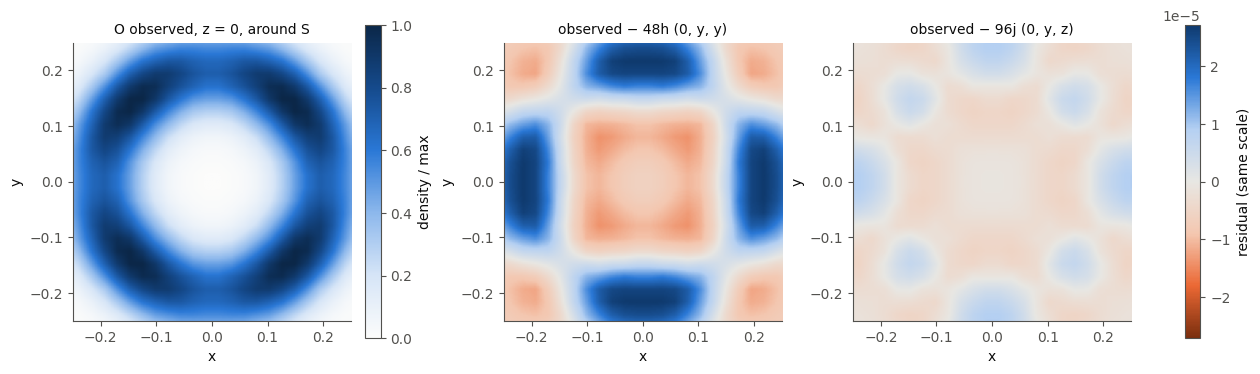

In [18]:
zoom = dict(origin=(-0.25, -0.25, 0), e1=(0.5, 0, 0), e2=(0, 0.5, 0))
o_plane = plane(O_norm, **zoom)
residuals = {
    name: o_plane - plane(fit.model_density / fit.model_density.sum(), **zoom)
    for name, fit in o_fits.items()
}
rmax = max(np.abs(r).max() for r in residuals.values())
extent = (-0.25, 0.25, -0.25, 0.25)

fig, axs = plt.subplots(1, 3, figsize=(12.5, 4), layout='constrained')
im = show(
    axs[0],
    o_plane / o_plane.max(),
    vmin=0,
    vmax=1,
    extent=extent,
    title='O observed, z = 0, around S',
)
fig.colorbar(im, ax=axs[0], shrink=0.8, label='density / max')
for ax, (name, res) in zip(axs[1:], residuals.items()):
    im = show(
        ax, res, cmap=DIV, vmin=-rmax, vmax=rmax, extent=extent, title=f'observed − {name}'
    )
fig.colorbar(im, ax=axs[1:], shrink=0.8, label='residual (same scale)')
plt.show()

96j wins clearly: R1 0.13 against 0.41 for 48h, and a residual several times weaker. One
Gaussian on the mirror cannot be both as long and as narrow as each lobe; two sites either
side of it can. The refined position (0, 0.099, 0.184) puts O 1.48 Å from S, and the six
superposed orientations of a sulfate ion it describes are the plastic-crystal disorder.

## 6. Summary

What each tool contributed to the average structure of α-Li₂SO₄ at 1000 K:

In [19]:
split, fit_O = li_fits['32f + 4b (split)'], o_fits['96j (0, y, z)']
tet, octa = split.sites
# the orbit member on the body diagonal, (x, x, x) with x < 1/2
x_32f = min(
    m[0]
    for m in wyckoff_orbit(fm3m, tet.position)
    if np.allclose(m, m[0], atol=1e-4) and m[0] < 0.5
)
fm3m_level = scan.ranking.match('Fm-3m')
fm3m_screen = next(row for row in screen if row['space group'] == 'Fm-3m')
pd.DataFrame(
    {
        'Crystallizer (peaks + framework)': {
            'space group': f'Fm-3m (from P1, P-1, Fm-3m; deviation {fm3m_level.deviation:.2f} Å)',
            'S': '4a',
            'Li, tetrahedral': f'8c ({n_li_peaks} peaks)',
            'Li, octahedral': 'not found',
            'O': 'not found (P1)',
        },
        'density method': {
            'space group': (
                f"Fm-3m: R_sym / R_noise = {fm3m_screen['R_sym / R_noise']}; "
                f"F-43m ΔBIC {ranking[1].ranking_metrics['bic'] - ranking[0].ranking_metrics['bic']:.0f} (noise)"
            ),
            'S': f'4a, U_iso {fit_S.sites[0].u_iso:.3f} Å²',
            'Li, tetrahedral': (
                f'32f, x = {x_32f:.3f} (split {tet.displacement:.2f} Å), '
                f'{tet.occupancy:.0%} of Li, U_iso {tet.u_iso:.3f} Å²'
            ),
            'Li, octahedral': f'4b, {octa.occupancy:.0%} of Li, U_iso {octa.u_iso:.3f} Å²',
            'O': (
                f'96j (0, {canonical(fit_O.sites[0].position)[1]:.3f}, {canonical(fit_O.sites[0].position)[2]:.3f}), '
                f'U_iso {fit_O.sites[0].u_iso:.3f} Å²'
            ),
        },
    }
)

,Crystallizer (peaks + framework),density method
space group,"Fm-3m (from P1, P-1, Fm-3m; deviation 0.20 Å)",Fm-3m: R_sym / R_noise = 1.04; F-43m ΔBIC 10 (...
S,4a,"4a, U_iso 0.126 Å²"
"Li, tetrahedral",8c (64 peaks),"32f, x = 0.278 (split 0.35 Å), 70% of Li, U_is..."
"Li, octahedral",not found,"4b, 30% of Li, U_iso 0.675 Å²"
O,not found (P1),"96j (0, 0.099, 0.184), U_iso 0.149 Å²"


- The **Crystallizer** narrowed the space group down in seconds, with no prior knowledge:
  P1, P-1 or Fm-3m, and it placed S and the tetrahedral Li.
- `from_crystallizer` handed those candidates to the density functions in the
  trajectory's own basis, including the sites to start from.
- The **density method** then decided between them and filled in what peak positions
  cannot show. Fm-3m is within the sampling noise, so the 0.2 Å deviation is scatter.
  The inversion centre that the Crystallizer cannot test holds. Li has a missed octahedral
  site holding 30 % of the density, and its tetrahedral site is split four ways. O, which
  gives no peaks, sits on 96j.

The same pattern applies to other systems: scan with the Crystallizer, pass each candidate
through `from_crystallizer`, screen it against the half-run noise, and refine the survivors
with `fit_density_model` and `rank_spacegroups`.